The Medical Costs case study for section 1

In [1]:
import pandas as pd

Get the data and read the data

In [2]:
df = pd.read_csv("C:/Users/misht/Downloads/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Before answering first question, tried to study age distribution  in the data

In [3]:
df["age"].describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

Question 1: How is age related to medical costs?

In [4]:
import seaborn as sns

[Text(0.5, 1.0, 'Age vs Medical Charges'),
 Text(0.5, 0, 'Age in Years'),
 Text(0, 0.5, 'Charges')]

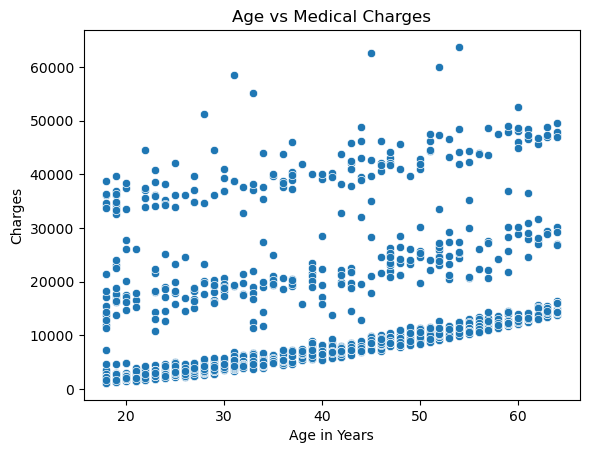

In [5]:
ax=sns.scatterplot(x="age", y="charges", data=df)
ax.set(
    title="Age vs Medical Charges",
    xlabel="Age in Years",
    ylabel="Charges"
)



As age increases, medical costs tend to increase.How to add a trendline to above plot?

[Text(0.5, 1.0, 'Age vs Medical Charges (Smoker vs Non Smoker)'),
 Text(0.5, 0, 'Age in Years'),
 Text(0, 0.5, 'Charges')]

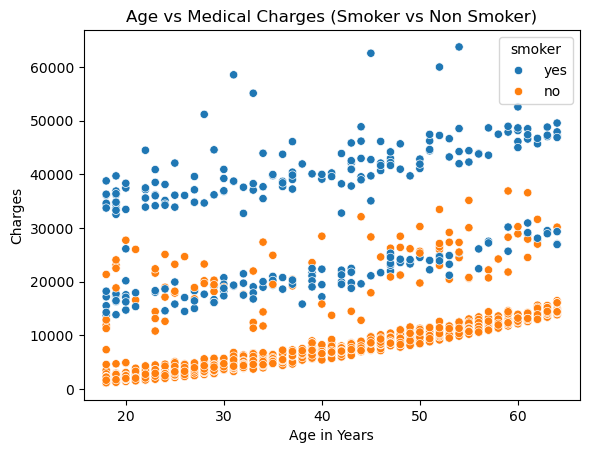

In [6]:
ax= sns.scatterplot(x="age", y="charges", hue="smoker", data=df)

ax.set(
    title="Age vs Medical Charges (Smoker vs Non Smoker)",
    xlabel="Age in Years",
    ylabel="Charges"
)


As age increases, medical costs tend to increase and smokers have significantly higher costs.

Question 2: How is number of children related to medical costs?

[Text(0.5, 1.0, 'Charges by Number of Children'),
 Text(0.5, 0, 'Number of Children'),
 Text(0, 0.5, 'Charges')]

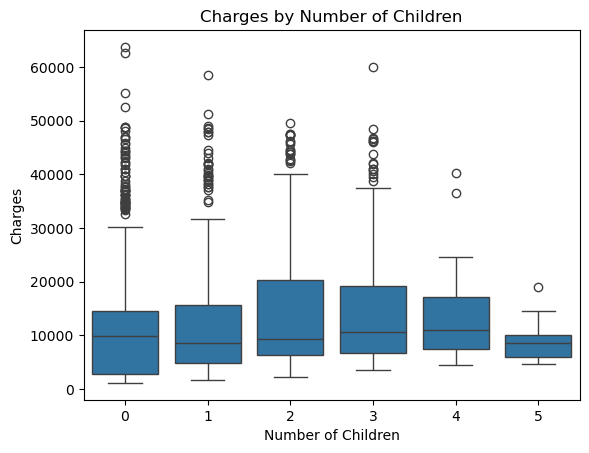

In [36]:
ax=sns.boxplot(x="children", y="charges", data=df)
ax.set(
title="Charges by Number of Children",
xlabel="Number of Children",
ylabel="Charges"
)

The median lines are close, showing that typical charges do not vary much with the number of children. 

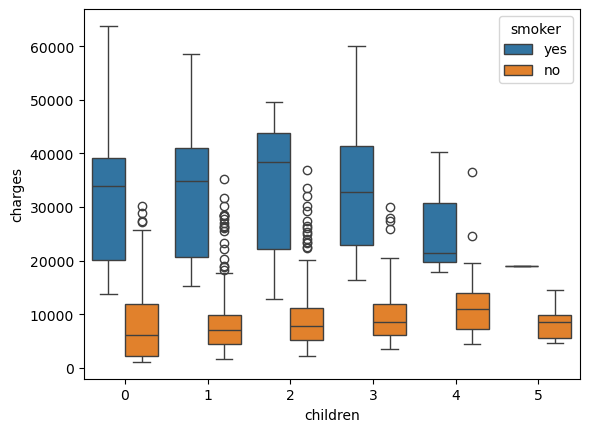

In [37]:
ax=sns.boxplot(x="children", y="charges", hue="smoker", data=df)
title="Charges by Number of Children (Smoker vs Non-Smoker)"
xlabel="Number of Children",
ylabel="Charges"

smokers have significantly higher charges than non-smokers across all groups.

Question 3: How is the number of people distributed by region?

[Text(0.5, 1.0, 'Number of People by Region'),
 Text(0.5, 0, 'Region'),
 Text(0, 0.5, 'Count')]

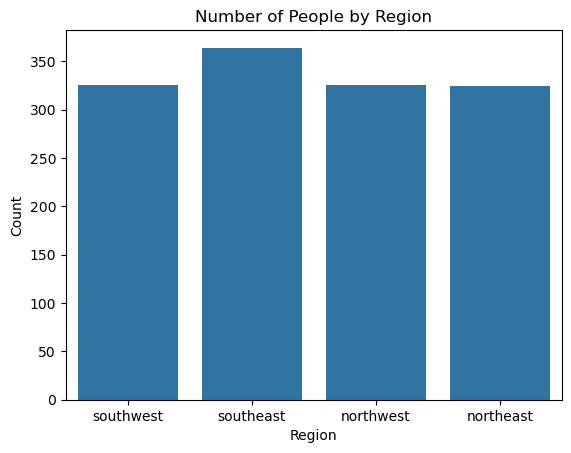

In [38]:
ax= sns.countplot(x="region", data=df)

ax.set(
    title="Number of People by Region",
    xlabel="Region",
    ylabel="Count"
)

Number of people is evenly distributed across all regions.

Question 4:How is the number of people distributed by age?

[Text(0.5, 1.0, 'Distribution of Age'),
 Text(0.5, 0, 'Age'),
 Text(0, 0.5, 'Frequency')]

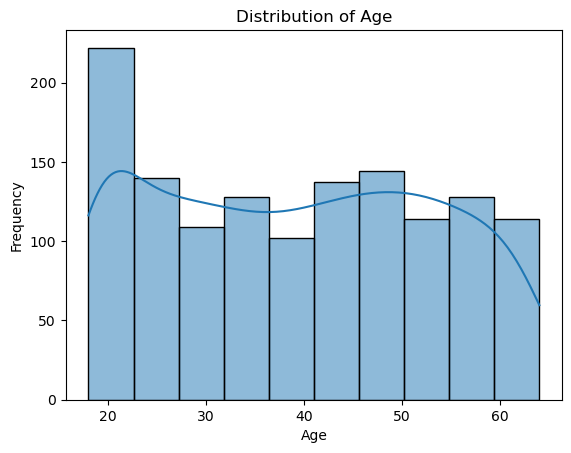

In [40]:
ax=sns.histplot(df["age"], bins=10, kde=True)

ax.set(
    title="Distribution of Age",
    xlabel="Age",
    ylabel="Frequency"
)

ages are fairly evenly distributed across the dataset

Question 5:How are the charges distributed?

[Text(0.5, 1.0, 'Distribution of Medical Charges'),
 Text(0.5, 0, 'Charges'),
 Text(0, 0.5, 'Frequency')]

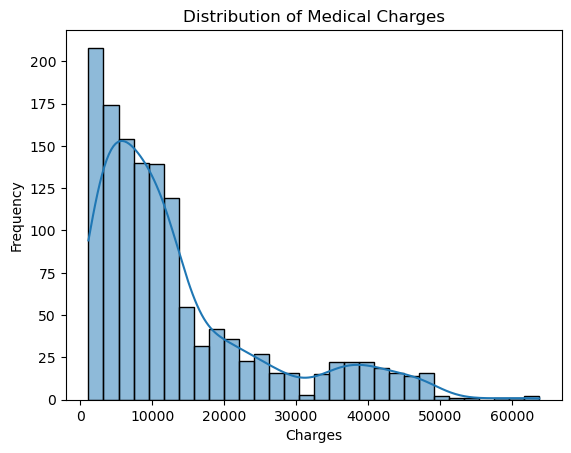

In [41]:
ax=sns.histplot(x="charges", data=df, kde=True)

ax.set(
    title="Distribution of Medical Charges",
    xlabel="Charges",
    ylabel="Frequency"
)

Most individuals have lower to moderate charges

The Medical Costs case study for section 2

BMI Categories
1. How are the charges related to the BMI?
2. How is the smoker status related to the charges?
3. How are the charges related to the region?
4. Which region has the highest obesity percentage?

In [42]:
import pandas as pd
df = pd.read_csv("C:/Users/misht/Downloads/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [43]:
# Bin the bmi column using CDC adult BMI classifications

def bmi_group(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Healthy Weight"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obesity"

df["bmi_group"] = df["bmi"].apply(bmi_group)

df[["bmi", "bmi_group"]].head()

,bmi,bmi_group
0,27.900,Overweight
1,33.770,Obesity
2,33.000,Obesity
3,22.705,Healthy Weight
4,28.880,Overweight


How are the charges related to the bmi?

In [44]:
# Examine BMI, BMI group, and charges to look for possible trends.
df[["bmi", "bmi_group", "charges"]].head(20) 

,bmi,bmi_group,charges
0,27.900,Overweight,16884.92400
1,33.770,Obesity,1725.55230
2,33.000,Obesity,4449.46200
3,22.705,Healthy Weight,21984.47061
4,28.880,Overweight,3866.85520
5,25.740,Overweight,3756.62160
6,33.440,Obesity,8240.58960
7,27.740,Overweight,7281.50560
8,29.830,Overweight,6406.41070
9,25.840,Overweight,28923.13692


[Text(0.5, 1.0, 'BMI vs Medical Charges by BMI Category'),
 Text(0.5, 0, 'BMI'),
 Text(0, 0.5, 'Charges')]

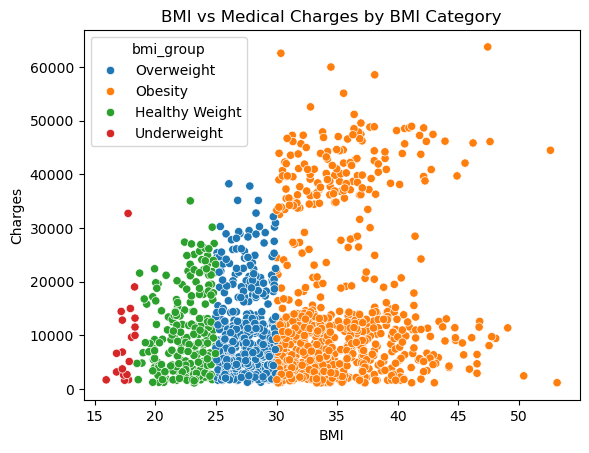

In [45]:
import seaborn as sns
ax = sns.scatterplot(
    x="bmi",
    y="charges",
    hue="bmi_group",
    data=df
)

ax.set(
    title="BMI vs Medical Charges by BMI Category",
    xlabel="BMI",
    ylabel="Charges"
)

In [46]:
# Calculate average medical charges for each BMI category to confirm charges increase with BMI.
avg_charges = df.groupby("bmi_group")["charges"].mean()

avg_charges = avg_charges.reindex([
    "Underweight",
    "Healthy Weight",
    "Overweight",
    "Obesity"
])
avg_charges

bmi_group
Underweight        8852.200585
Healthy Weight    10409.337709
Overweight        10987.509891
Obesity           15552.335469
Name: charges, dtype: float64

[Text(0.5, 1.0, 'Average Medical Charges by BMI Category'),
 Text(0.5, 0, 'BMI Category'),
 Text(0, 0.5, 'Average Charges')]

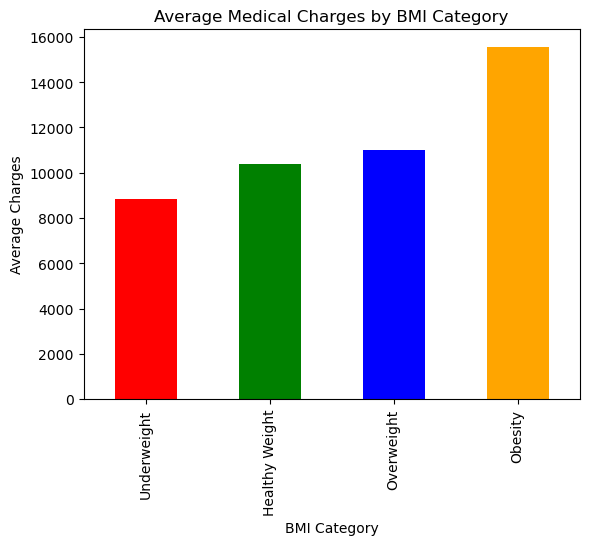

In [47]:
colors = ["red", "green", "blue", "orange"]

ax = avg_charges.plot.bar(color=colors)

ax.set(
    title="Average Medical Charges by BMI Category",
    xlabel="BMI Category",
    ylabel="Average Charges"
)

Average values shows a better/prettier trend than raw scatter values

How is smoker status related to charges?

[Text(0.5, 1.0, 'Medical Charges by Smoker Status'),
 Text(0.5, 0, 'Smoker Status'),
 Text(0, 0.5, 'Charges')]

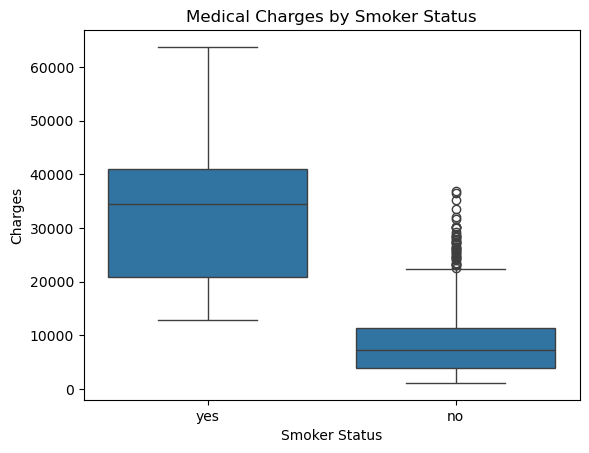

In [48]:

ax = sns.boxplot(x="smoker", y="charges", data=df)

ax.set(
    title="Medical Charges by Smoker Status",
    xlabel="Smoker Status",
    ylabel="Charges"
)

[Text(0.5, 1.0, 'Medical Charges by Region'),
 Text(0.5, 0, 'Region'),
 Text(0, 0.5, 'Charges')]

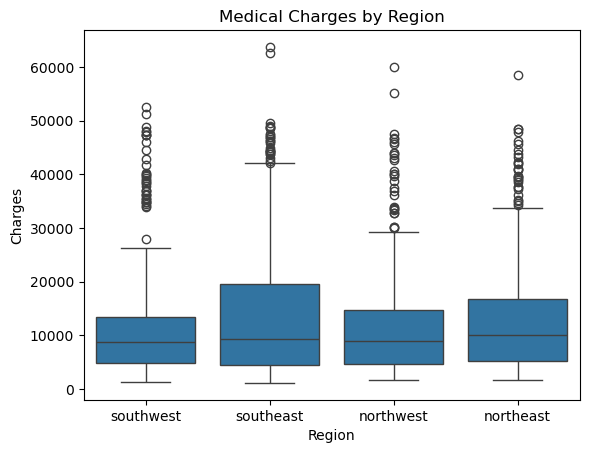

In [49]:
ax = sns.boxplot(x="region", y="charges", data=df)

ax.set(
    title="Medical Charges by Region",
    xlabel="Region",
    ylabel="Charges"
)

Answer 3: The median charge lines are similar across regions, and the boxes indicate that medical charges do not differ substantially by region.

Which region has the highest obesity percentage?

check bmi_group in data 

In [50]:
df[["region", "bmi", "bmi_group"]].head()

,region,bmi,bmi_group
0,southwest,27.900,Overweight
1,southeast,33.770,Obesity
2,southeast,33.000,Obesity
3,northwest,22.705,Healthy Weight
4,northwest,28.880,Overweight


Add obese/not obese column

In [51]:
df["is_obese"] = df["bmi_group"] == "Obesity"

df[["region", "bmi_group", "is_obese"]].head()

,region,bmi_group,is_obese
0,southwest,Overweight,False
1,southeast,Obesity,True
2,southeast,Obesity,True
3,northwest,Healthy Weight,False
4,northwest,Overweight,False


Count total number of people in each region

In [52]:
region_total = df.groupby("region")["is_obese"].count()

region_total

region
northeast    324
northwest    325
southeast    364
southwest    325
Name: is_obese, dtype: int64

Count total number of obese people in each region

In [53]:
region_obese = df.groupby("region")["is_obese"].sum()

region_obese

region
northeast    143
northwest    148
southeast    243
southwest    173
Name: is_obese, dtype: int64

Calculate obesity percentage

In [54]:
obesity_percent = region_obese / region_total * 100

obesity_percent

region
northeast    44.135802
northwest    45.538462
southeast    66.758242
southwest    53.230769
Name: is_obese, dtype: float64

Sort data before plotting

In [55]:
obesity_percent.sort_values(ascending=False)

region
southeast    66.758242
southwest    53.230769
northwest    45.538462
northeast    44.135802
Name: is_obese, dtype: float64

[Text(0.5, 1.0, 'Obesity Percentage by Region'),
 Text(0.5, 0, 'Region'),
 Text(0, 0.5, 'Obesity Percentage')]

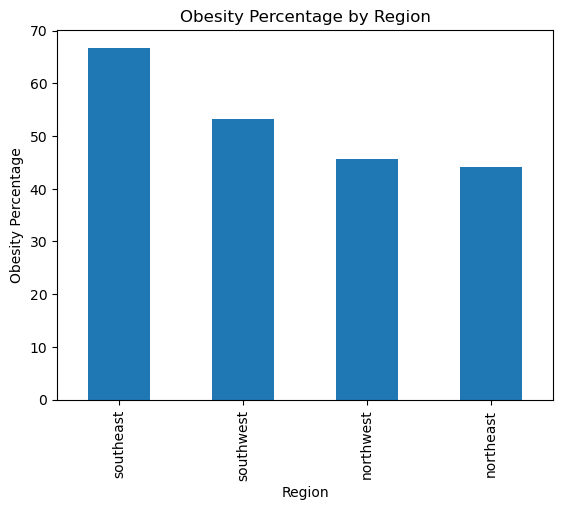

In [56]:
ax = obesity_percent.sort_values(ascending=False).plot.bar()

ax.set(
    title="Obesity Percentage by Region",
    xlabel="Region",
    ylabel="Obesity Percentage"
)

The region with the highest obesity percentage is Southeast